# WBGT variants from ERA5 vs WBGT-ERA5-v2.0 (Li et al. 2020), 1979

Compute thermodynamic wet-bulb and three WBGT variants from ERA5, and compare the shaded WBGT against the published WBGT-ERA5-v2.0 gridded product (Li, Yuan & Kopp 2020, *Environ. Res. Lett.* **15** 064003).

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

ROOT = '/glade/derecho/scratch/gavinmad/shared/Heathack'
sys.path.insert(0, f'{ROOT}/src')
from heathack import era5, era5_fc, thermo

### Venues and period
Eight 1979 grid points at the 2018 host-city stadiums (mix of inland and Black Sea / Baltic coastal sites), June–July.

In [2]:
venues = pd.read_csv(f'{ROOT}/data/raw/fifa/venues_all.csv')
keep = ['Volgograd Arena', 'Rostov Arena', 'Samara Arena', 'Fisht Olympic Stadium',
        'Saint Petersburg Stadium', 'Kaliningrad Stadium', 'Luzhniki Stadium',
        'Nizhny Novgorod Stadium']
sel = venues[(venues.year == 2018) & (venues.stadium.isin(keep))].reset_index(drop=True)
points = [(r.stadium, r.lat, r.lon) for r in sel.itertuples()]
coords = {r.stadium: (r.lat, r.lon) for r in sel.itertuples()}
months = [197906, 197907]
sel[['stadium', 'city', 'lat', 'lon']]

,stadium,city,lat,lon
0,Luzhniki Stadium,Moscow,55.71583,37.55361
1,Saint Petersburg Stadium,Saint Petersburg,59.97300,30.22050
2,Fisht Olympic Stadium,Sochi,43.40227,39.95611
3,Kaliningrad Stadium,Kaliningrad,54.69806,20.53389
4,Nizhny Novgorod Stadium,Nizhny Novgorod,56.33750,43.96333
5,Samara Arena,Samara,53.27778,50.23722
6,Rostov Arena,Rostov-on-Don,47.20944,39.73778
7,Volgograd Arena,Volgograd,48.73444,44.54861


### Extract ERA5
Analysis fields (2 m temperature, 2 m dewpoint, surface pressure, 10 m wind) and forecast shortwave (SSRD, FDIR).

In [3]:
anl = {v: era5.extract_points_range(v, months, points) for v in ['t2m', 'd2m', 'sp', 'u10', 'v10']}
ssrd = era5_fc.extract_flux_points('ssrd', months, points)
fdir = era5_fc.extract_flux_points('fdir', months, points)

### WBGT variants
- `Tw`  – thermodynamic wet-bulb (Stull 2011)
- `WBGT_shade` = 0.7·Tw + 0.3·Ta  (shaded; the form used by Li et al. 2020)
- `sWBGT` – simplified WBGT (Australian BoM regression)
- `WBGT_sun` – outdoor Liljegren WBGT with solar/wind load (thermofeel)

In [4]:
def wbgt_variants(name):
    d = pd.DataFrame({v: anl[v][name] for v in anl}).dropna()
    Ta = thermo.k2c(d.t2m)
    Td = thermo.k2c(d.d2m)
    rh = thermo.rh_from_t_td(Ta, Td)
    tw = thermo.wet_bulb_stull(Ta, rh)
    s = ssrd[name].reindex(d.index)
    f = fdir[name].reindex(d.index)
    frac = (f / s.where(s > 1)).fillna(0).clip(0, 0.9)      # direct-beam fraction
    cz = thermo.cos_solar_zenith(d.index, *coords[name])
    out = pd.DataFrame(index=d.index)
    out['Ta'] = Ta
    out['Tw'] = tw
    out['WBGT_shade'] = 0.7 * tw + 0.3 * Ta
    out['sWBGT'] = thermo.wbgt_shade_bom(Ta, thermo.vapor_pressure_hpa(Td))
    out['WBGT_sun'] = thermo.wbgt_liljegren(d.t2m, rh, d.sp / 100,
                                            thermo.wind_speed(d.u10, d.v10), s, frac, cz)
    return out

wb = {name: wbgt_variants(name) for name, _, _ in points}
wb['Volgograd Arena'].describe().round(1)

,Ta,Tw,WBGT_shade,sWBGT,WBGT_sun
count,1464.0,1464.0,1464.0,1464.0,1464.0
mean,21.9,14.7,16.8,21.2,18.1
std,5.2,3.0,3.4,3.3,4.3
min,7.4,4.7,6.1,11.4,6.0
25%,18.4,12.8,14.9,19.2,15.5
50%,21.6,15.2,17.2,21.4,18.3
75%,25.5,16.8,19.1,23.3,21.1
max,36.1,21.1,24.3,28.6,28.3


### WBGT-ERA5-v2.0 (Li et al. 2020)
1° hourly `wbgt` (= 0.7·Tw + 0.3·Ta), read at the nearest grid cell to each venue.

In [5]:
li = xr.open_mfdataset(sorted(glob.glob(f'{ROOT}/data/staging/li2020/wbgt_1979-0[67].nc')))['wbgt'] - 273.15

def li_at(lat, lon):
    s = li.sel(latitude=lat, longitude=lon, method='nearest').to_series()
    s.index = pd.to_datetime(s.index)
    return s

ERROR 1: PROJ: proj_create_from_database: Open of /glade/u/apps/opt/conda/envs/npl-2025b/share/proj failed


### Time series at one venue

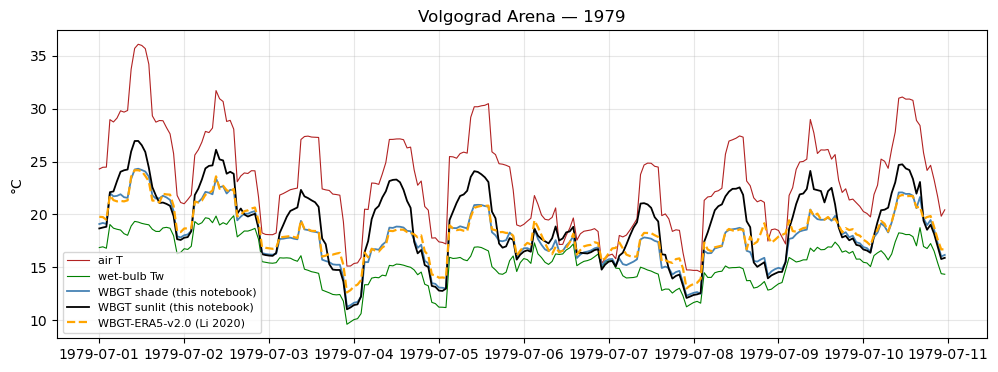

In [6]:
name = 'Volgograd Arena'
w = wb[name]
l = li_at(*coords[name]).reindex(w.index)
win = slice('1979-07-01', '1979-07-10')
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(w.loc[win, 'Ta'], color='firebrick', lw=0.8, label='air T')
ax.plot(w.loc[win, 'Tw'], color='green', lw=0.8, label='wet-bulb Tw')
ax.plot(w.loc[win, 'WBGT_shade'], color='steelblue', lw=1.3, label='WBGT shade (this notebook)')
ax.plot(w.loc[win, 'WBGT_sun'], color='black', lw=1.3, label='WBGT sunlit (this notebook)')
ax.plot(l.loc[win], color='orange', lw=1.6, ls='--', label='WBGT-ERA5-v2.0 (Li 2020)')
ax.set_ylabel('°C'); ax.set_title(f'{name} — 1979'); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.show()

### Shaded WBGT vs WBGT-ERA5-v2.0 — per venue

In [7]:
rows, xs, ys = [], [], []
for name in coords:
    w = wb[name]
    l = li_at(*coords[name]).reindex(w.index)
    m = pd.DataFrame({'ours': w.WBGT_shade, 'li': l}).dropna()
    xs += list(m.li); ys += list(m.ours)
    diff = m.ours - m.li
    rows.append({'venue': name, 'n': len(m), 'bias_C': round(diff.mean(), 2),
                 'rmse_C': round(np.sqrt((diff ** 2).mean()), 2), 'r': round(m.ours.corr(m.li), 3)})
tab = pd.DataFrame(rows).sort_values('rmse_C')
tab

,venue,n,bias_C,rmse_C,r
4,Nizhny Novgorod Stadium,1464,0.02,0.27,0.998
6,Rostov Arena,1464,-0.07,0.38,0.992
5,Samara Arena,1464,-0.10,0.39,0.997
0,Luzhniki Stadium,1464,0.06,0.45,0.991
7,Volgograd Arena,1464,-0.44,0.87,0.977
3,Kaliningrad Stadium,1464,-0.02,1.62,0.861
1,Saint Petersburg Stadium,1464,1.60,1.87,0.944
2,Fisht Olympic Stadium,1464,-2.88,3.11,0.813


Coastal sites (Sochi/Fisht, Saint Petersburg, Kaliningrad) show the largest RMSE — Li's 1° cell mixes land and sea where our 0.25° cell does not. Inland sites agree closely.

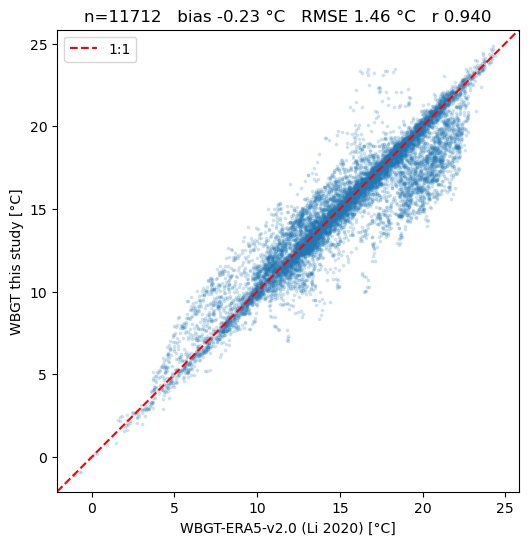

In [8]:
xs, ys = np.array(xs), np.array(ys)
lim = [min(xs.min(), ys.min()) - 1, max(xs.max(), ys.max()) + 1]
bias = (ys - xs).mean(); rmse = np.sqrt(((ys - xs) ** 2).mean()); r = np.corrcoef(xs, ys)[0, 1]
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(xs, ys, s=3, alpha=0.15)
ax.plot(lim, lim, 'r--', label='1:1')
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
ax.set_xlabel('WBGT-ERA5-v2.0 (Li 2020) [°C]'); ax.set_ylabel('WBGT this study [°C]')
ax.set_title(f'n={len(xs)}   bias {bias:+.2f} °C   RMSE {rmse:.2f} °C   r {r:.3f}')
ax.legend()
os.makedirs(f'{ROOT}/figures/02_wetbulb', exist_ok=True)
fig.savefig(f'{ROOT}/figures/02_wetbulb/li2020_wbgt_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

The shaded WBGT computed here reproduces WBGT-ERA5-v2.0 to within a small mean bias, confirming the wet-bulb and WBGT calculation. The Liljegren (sunlit) variant sits above it by the solar globe term, which Li et al.'s shaded index omits.

## FIFA host cities and the change in WBGT

Map: land-only WBGT change, mean(1996\u20132025) minus mean(1961\u20131990), computed from the hourly ERA5 record (1940\u20132025). Insets: annual WBGT at selected host cities, 1940\u20132025, with a linear trend; the shaded band marks the tournament year(s) at that city.

In [9]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import ConnectionPatch

# WBGT change field, precomputed with dask (scripts/52_global_wbgt_diff.py).
# For heavier hourly/global work, scale onto a Casper PBS cluster:
#     from dask_jobqueue import PBSCluster
#     from dask.distributed import Client
#     cluster = PBSCluster(cores=1, memory='4GiB', processes=1,
#                          resource_spec='select=1:ncpus=1:mem=4GB', queue='casper',
#                          walltime='00:30:00', interface='ext', account='UCLA0076')
#     cluster.scale(16); client = Client(cluster); client.wait_for_workers(16)
dw = xr.open_dataarray(f'{ROOT}/data/processed/global_wbgt_diff.nc')
dw = dw.assign_coords(longitude=(((dw.longitude + 180) % 360) - 180)).sortby('longitude')
va = pd.read_csv(f'{ROOT}/results/tables/venue_annual_wbgt.csv')

In [10]:
def city_series(key):
    sub = va[va.city.str.contains(key, case=False, na=False)]
    if sub.empty:
        return None
    return va[va.venue == sub.venue.iloc[0]].sort_values('year')

def city_tours(key):
    sub = va[va.city.str.contains(key, case=False, na=False)]
    return sorted(sub.tour.unique())

north = ['Mexico City', 'Orlando', 'Doha', 'Rostov', 'Yokohama', 'Rome', 'London']
south = ['Manaus', 'Fortaleza', 'Rio de Janeiro', 'Buenos Aires', 'Johannesburg']
series = {k: city_series(k) for k in north + south}
series = {k: s for k, s in series.items() if s is not None}
[k for k in series]

['Mexico City',
 'Orlando',
 'Doha',
 'Rostov',
 'Yokohama',
 'Rome',
 'London',
 'Manaus',
 'Fortaleza',
 'Rio de Janeiro',
 'Buenos Aires',
 'Johannesburg']

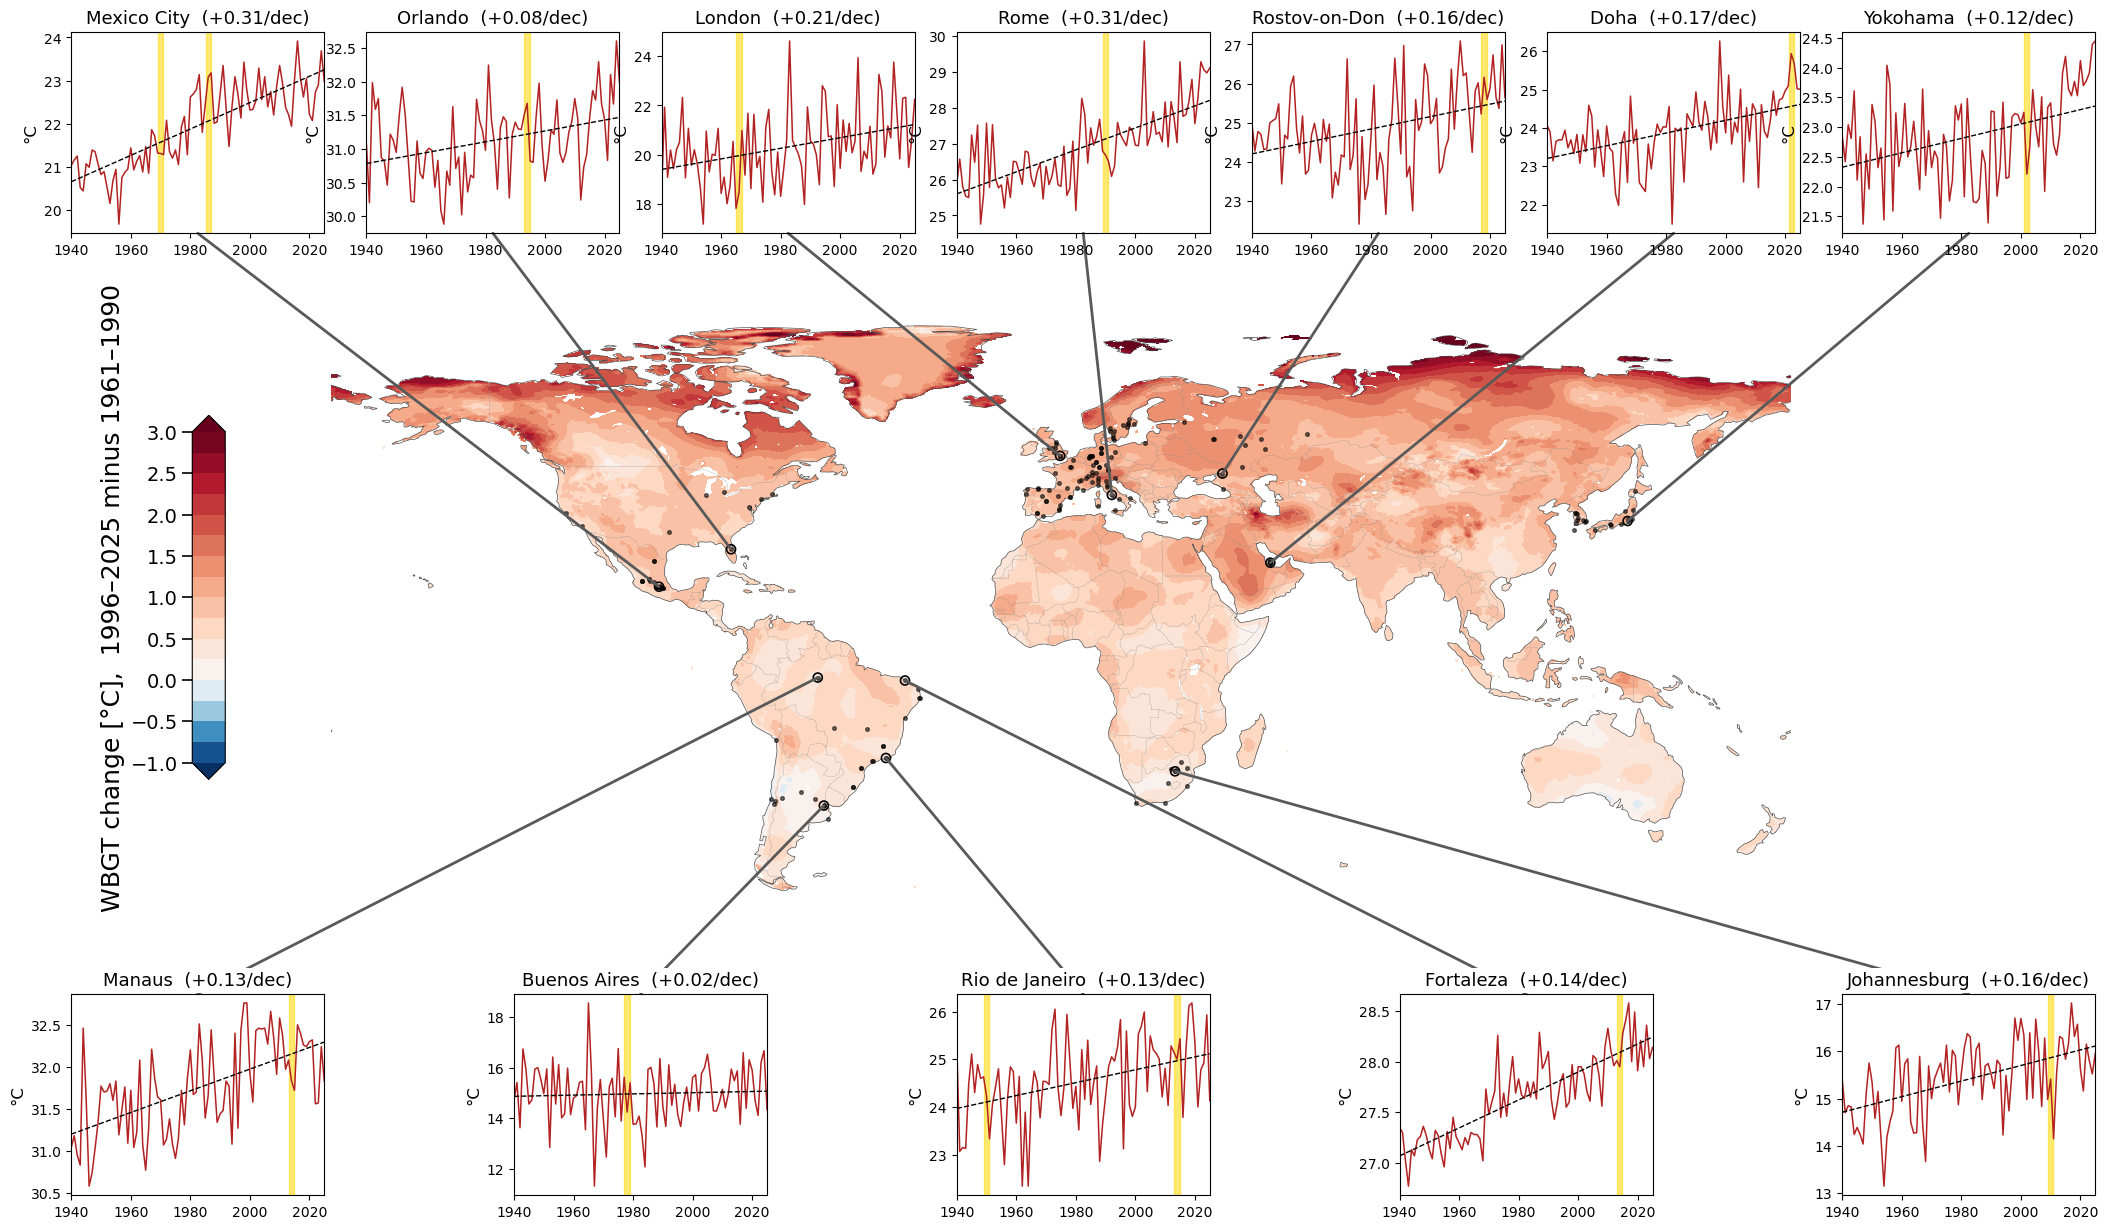

In [11]:
import matplotlib.colors as mcolors
fig = plt.figure(figsize=(22, 13))
axm = fig.add_axes([0.16, 0.28, 0.68, 0.44], projection=ccrs.PlateCarree())
axm.set_extent([-180, 180, -57, 84], crs=ccrs.PlateCarree())   # drop Antarctica; natural aspect
axm.spines['geo'].set_visible(False)                                                   # no outer box
axm.coastlines(lw=0.5, color='0.3'); axm.add_feature(cfeature.BORDERS, lw=0.2, edgecolor='0.55')
lv = np.arange(-1.0, 3.01, 0.25)
cf = axm.contourf(dw.longitude, dw.latitude, dw, levels=lv, cmap='RdBu_r',
                  norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-1.0, vmax=3.0),
                  extend='both', transform=ccrs.PlateCarree())
# colorbar on the LEFT, close to the map; its label is the only descriptor (no figure title)
cax = fig.add_axes([0.105, 0.37, 0.015, 0.28])
cb = fig.colorbar(cf, cax=cax, orientation='vertical')
cax.yaxis.set_ticks_position('left'); cax.yaxis.set_label_position('left')
cb.set_label('WBGT change [\u00b0C],  1996\u20132025 minus 1961\u20131990', fontsize=18)
cb.ax.tick_params(labelsize=14, length=7, width=1.2)
allc = va.drop_duplicates('venue')
axm.scatter(allc.lon, allc.lat, s=7, c='k', alpha=0.55, transform=ccrs.PlateCarree(), zorder=5)

def draw_row(keys, y0, top):
    keys = [k for k in keys if k in series]
    keys.sort(key=lambda k: series[k].lon.iloc[0])
    n = len(keys); w = 0.115; gap = (0.92 - n * w) / max(n - 1, 1)
    for i, k in enumerate(keys):
        s = series[k]; yr = s.year.values; wb = s.wbgt_sun.values
        ax = fig.add_axes([0.05 + i * (w + gap), y0, w, 0.155])
        for ty in city_tours(k):
            ax.axvspan(ty - 0.9, ty + 0.9, color='gold', alpha=0.55, zorder=0)
        ax.plot(yr, wb, lw=1.1, color='firebrick')
        m, b = np.polyfit(yr, wb, 1); ax.plot(yr, m * yr + b, 'k--', lw=1.0)
        label = f"{s.city.iloc[0].split(',')[0].strip()}  ({m*10:+.2f}/dec)"
        # both rows get a title; the opaque white box keeps the connector from showing through it
        ax.set_title(label, fontsize=13, zorder=10,
                     bbox=dict(facecolor='white', edgecolor='none', pad=2.5))
        ax.set_ylabel('\u00b0C', fontsize=12)
        ax.tick_params(labelsize=10); ax.margins(x=0)
        lonc, latc = s.lon.iloc[0], s.lat.iloc[0]
        axm.scatter([lonc], [latc], s=42, facecolor='none', edgecolor='k', lw=1.2,
                    transform=ccrs.PlateCarree(), zorder=6)
        con = ConnectionPatch(xyA=(lonc, latc), coordsA=axm.transData,
                              xyB=(0.5, 0.0 if top else 1.0), coordsB=ax.transAxes,
                              color='0.35', lw=2.0, zorder=1)
        con.set_clip_on(False); ax.add_artist(con)

draw_row(north, 0.79, True)
draw_row(south, 0.05, False)
plt.show()

Notes: What is plotted is the mean of the months when the games were on for the daily max WBGT. Every host city has warmed (positive slope; gold band = tournament year). The change map (red = warming) shows the strongest increases over land at low latitudes and the mid-latitude interiors.